In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


<Axes: >

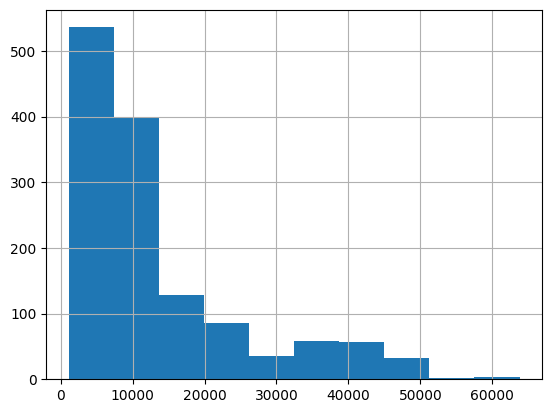

In [1]:
import pandas as pd

insurance = pd.read_csv("insurance.csv")

insurance['charges'].describe()
insurance['charges'].hist()
#credit_train = credit_rand.iloc[0:901]
#credit_test = credit_rand.iloc[901:]

In [8]:
print(insurance.corr(numeric_only=True))

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


array([[<Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='bmi', ylabel='age'>,
        <Axes: xlabel='children', ylabel='age'>,
        <Axes: xlabel='charges', ylabel='age'>],
       [<Axes: xlabel='age', ylabel='bmi'>,
        <Axes: xlabel='bmi', ylabel='bmi'>,
        <Axes: xlabel='children', ylabel='bmi'>,
        <Axes: xlabel='charges', ylabel='bmi'>],
       [<Axes: xlabel='age', ylabel='children'>,
        <Axes: xlabel='bmi', ylabel='children'>,
        <Axes: xlabel='children', ylabel='children'>,
        <Axes: xlabel='charges', ylabel='children'>],
       [<Axes: xlabel='age', ylabel='charges'>,
        <Axes: xlabel='bmi', ylabel='charges'>,
        <Axes: xlabel='children', ylabel='charges'>,
        <Axes: xlabel='charges', ylabel='charges'>]], dtype=object)

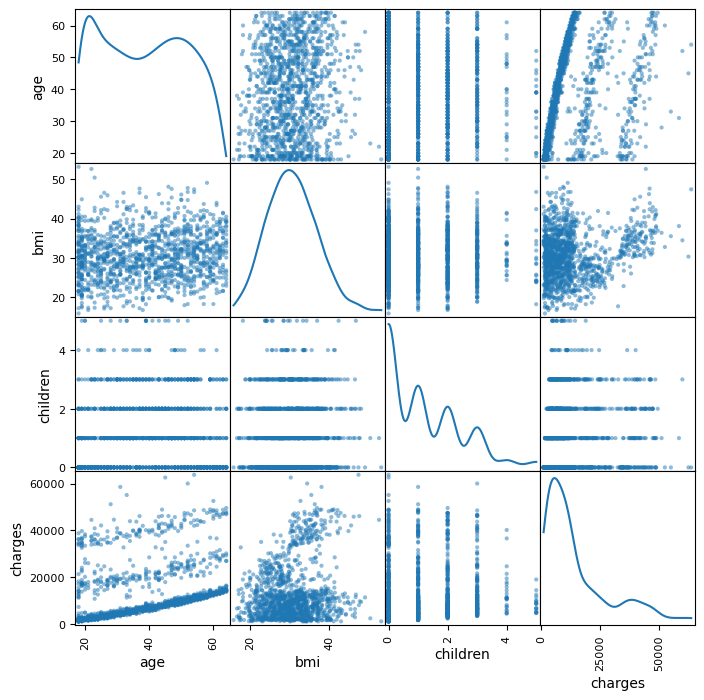

In [14]:
from pandas.plotting import scatter_matrix
scatter_matrix(insurance, figsize=(8, 8), diagonal='kde')
#RELAÇÕES: age and charges || bmi and charges

In [28]:
import pandas as pd
from sklearn.linear_model import LinearRegression

#alvo
y = insurance['charges']

#numéricas
numeric_features = ['age', 'bmi', 'children']

#categóricas
categorical_features = ['sex', 'smoker', 'region']

X_num = insurance[numeric_features]
X_cat = insurance[categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'  #mantm colunas numéricas sem alteração
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
model.fit(X, y)
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

print("Intercepto:", model.named_steps['regressor'].intercept_)
print("Coeficientes:")
for name, coef in zip(feature_names, model.named_steps['regressor'].coef_):
    print(f"  {name}: {coef}")


Intercepto: -11938.538576167088
Coeficientes:
  cat__sex_male: -131.31435939510942
  cat__smoker_yes: 23848.534541912824
  cat__region_northwest: -352.9638994246362
  cat__region_southeast: -1035.0220493878358
  cat__region_southwest: -960.0509913008484
  remainder__age: 256.85635253734654
  remainder__bmi: 339.19345361083833
  remainder__children: 475.5005451491279


In [ ]:
"""
Transcrevendo o ins_model para o python, relacionamos as 6 variaveis independentes ao total medical charges
e a leitura a ser feita já está em valores do quanto o charge aumenta para cada variável, 
então por exemplo, envelhecer ano após ano adiciona 256, em média, no charge, sendo o mais significativo a variável fumar,
com impressionantes 23848 de valor de beta.

as outras não numéricas foram atribuidas valores atrvés do dummy coding (uma categoria vira base, não ganha coluna)

relações lineares são intuitivas para associarmos, como as citadas acima, talvez a não tão evidente é a de filhos, que não necessariamente degradam a saúde
e causam maior custo pro plano, mas ao adicionar um filho no convenio, aumentam as depesas.
"""

In [29]:
from sklearn.metrics import r2_score, mean_squared_error

# Fazer predição no treino (exemplo)
y_pred = model.predict(X)

# R2
print("R²:", r2_score(y, y_pred))

# RMSE
print("RMSE:", mean_squared_error(y, y_pred, squared=False))

R²: 0.7509130345985207
RMSE: 6041.6796511744515


/home/ufabc/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [30]:
import statsmodels.formula.api as smf
import pandas as pd

model = smf.ols('charges ~ age + children + bmi + sex + smoker + region', data=insurance).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Tue, 21 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:24:32   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.194e+04    

In [ ]:
"""
Tratando-se do quão bem o modelo deu fit com os dados
o valor residual é igual ao valor real menos o previsto, mas não é mostrado nessa adptação
mas conseguimos com o método dos Rs quadrados, ver o quão bem nosso modelo linear conseguiu explicar os dados
pois 75% dos da variação na variável dependente é explicada pelo nosso modelo
"""

In [31]:
insurance_mod = insurance
insurance_mod['age2'] = insurance_mod['age'] ** 2
insurance_mod['bmi30'] = (insurance_mod['bmi'] >= 30).astype(int)

In [33]:
import statsmodels.formula.api as smf

formula = 'charges ~ age + age2 + children + bmi + sex + bmi30*smoker + region'

model2 = smf.ols(formula=formula, data=insurance_mod).fit()

print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     781.7
Date:                Tue, 21 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:34:10   Log-Likelihood:                -13131.
No. Observations:                1338   AIC:                         2.629e+04
Df Residuals:                    1326   BIC:                         2.635e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             134.2509   1

In [1]:
"""
Chegamos no mesmo resultado do LANTZ, adaptando a visão do R com a lib
statsmodels.formula.api, onde comparado com o primeiro, saltamos de 0,751 para 0,866
uma melhora expressiva ao testarmos a hipótese final do capitulo de
'e se algumas features tiverem um impacto combinado numa variável dependente' -> interação
ex: fumar e obsidade
onde as melhorias de criação de termo não linear para idade, indicador de obesidade e interação de obsidade+fumar
contribuiram para capturas padrões que o linear puro não pegou:
-idade tende a ter efeito não linear
-IMC mostra um efeito de limiar forte quando IMC ≥ 30
-fumar e ser obeso, interagem, o impacto de ser fumante é ainda maior quando a pessoa é obesa (de 13k de custo para 19k de custo)
"""

"\nChegamos no mesmo resultado do LANTZ, adaptando a visão do R com a lib\nstatsmodels.formula.api, onde comparado com o primeiro, saltamos de 0,751 para 0,866\numa melhora expressiva ao testarmos a hipótese final do capitulo de\n'e se algumas features tiverem um impacto combinado numa variável dependente' -> interação\nex: fumar e obsidade\nonde as melhorias de criação de termo não linear para idade, indicador de obesidade e interação de obsidade+fumar\ncontribuiram para capturas padrões que o linear puro não pegou:\n-idade tende a ter efeito não linear\n-IMC mostra um efeito de limiar forte quando IMC ≥ 30\n-fumar e ser obeso, interagem, o impacto de ser fumante é ainda maior quando a pessoa é obesa (de 13k de custo para 19k de custo)\n"